---

### Problem Statement — Whether it Requires ML

**About Dataset**  
The Student Performance Dataset is designed to examine the factors influencing academic performance. It consists of 10,000 student records, with each record containing information about various predictors (independent variables) and a performance index (target variable).

**Variables:**  
- **Hours Studied:** Total number of hours spent studying by each student.  
- **Previous Scores:** Scores obtained by students in previous tests.  
- **Extracurricular Activities:** Whether the student participates in extracurricular activities (Yes/No).  
- **Sleep Hours:** Average number of hours of sleep per day.  
- **Sample Question Papers Practiced:** Number of sample question papers the student practiced.  
- **Data Set:** https://raw.githubusercontent.com/DataScience75/Cohort130/refs/heads/main/Student_Performance.csv

**Target Variable:**  
- **Performance Index:** A measure of overall student performance, rounded to the nearest integer. The index ranges from 10 to 100, with higher values indicating better performance.  

This dataset aims to provide insights into the relationship between the predictor variables and the performance index. Researchers and data analysts can use it to explore the impact of study habits, prior scores, extracurricular involvement, sleep, and practice on student performance.

---



### Accuracy in machine learning is also called as Accuracy Score (r2_score) is a performance metric that tells us how often the model’s predictions are correct compared to the actual outcomes.
(The formula is  :  Accuracy = Number of Correct Predictions / Total Predictions × 100)

**Suppose we build a classification model to predict whether emails are Spam or Not Spam.**
- Total emails tested: 100
- Model predictions: Correctly predicted Spam: 40, Correctly predicted Not Spam: 50, Wrong predictions: 10
- SO, accuracy = 40 + 50/100 = 90/100 = 90%

---




Read the data in Python  
Do some basic exploratory analysis (EDA)
- How many rows and how many columns  
- How many missing values in each column  
- How many object data type columns and what are the different distinct categories they have  
- What is the correlation between each of the independent variables  
- Plot the distributions for each of the variables  

---  

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = 'D:/Works/Top Mentor/Python/DataSet/Student_Performance.csv'


In [3]:
data = pd.read_csv(path)
data.head(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0


In [4]:
data.shape      # No. of rows and columns

(10000, 6)

In [5]:
data.isnull().sum()         # Checking null values

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
data.dtypes         # Checking data types

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [7]:
data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [8]:
# Showing all the unique values in each column

for i in data:
    print("Columns: ", i)
    print("Values: ", data[i].unique())
    print("----"*15)

Columns:  Hours Studied
Values:  [7 4 8 5 3 6 2 1 9]
------------------------------------------------------------
Columns:  Previous Scores
Values:  [99 82 51 52 75 78 73 45 77 89 91 79 47 72 83 54 96 74 85 61 62 84 94 90
 44 70 67 97 59 55 68 63 46 76 43 81 93 98 48 92 64 88 60 87 40 69 80 95
 49 50 53 71 56 58 66 65 57 41 42 86]
------------------------------------------------------------
Columns:  Extracurricular Activities
Values:  ['Yes' 'No']
------------------------------------------------------------
Columns:  Sleep Hours
Values:  [9 4 7 5 8 6]
------------------------------------------------------------
Columns:  Sample Question Papers Practiced
Values:  [1 2 5 6 0 8 3 4 9 7]
------------------------------------------------------------
Columns:  Performance Index
Values:  [ 91.  65.  45.  36.  66.  61.  63.  42.  69.  84.  73.  27.  33.  68.
  43.  67.  70.  30.  71.  85.  57.  35.  49.  83.  74.  39.  58.  47.
  60.  32.  64.  54.  17.  53.  75.  52.  78.  38.  98.  87.  41. 

In [9]:
data.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [10]:
# Mapping text columns to numerical so we can perform correlation as it works only for numerical columns.
# 

d = {'Yes': 1, 'No': 0}
data['Extracurricular Activities'] = data['Extracurricular Activities'].map(d)

In [11]:
data['Extracurricular Activities'].head(3)

0    1
1    0
2    1
Name: Extracurricular Activities, dtype: int64

In [12]:
# All the columns are numerical

data.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


<Axes: >

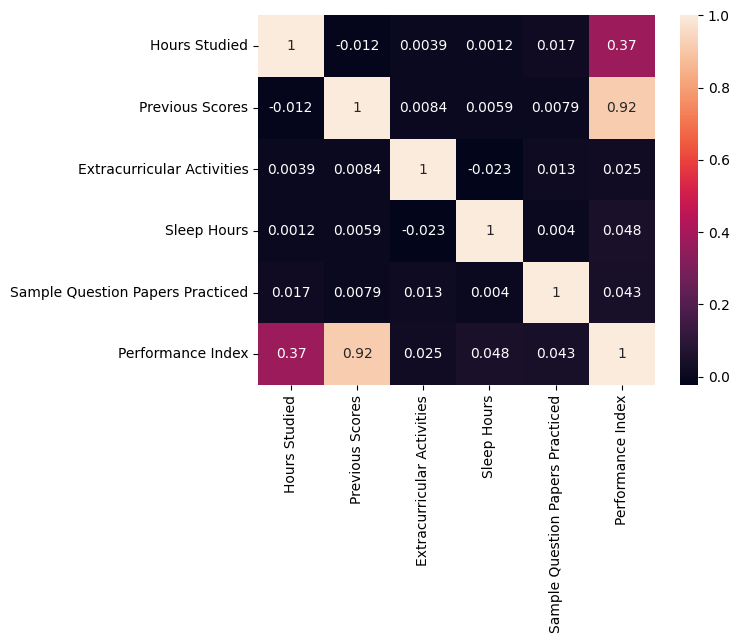

In [13]:
# Corelation of each variable using heatmap

sns.heatmap(data.corr(), annot=True)

-0.004212515950724343


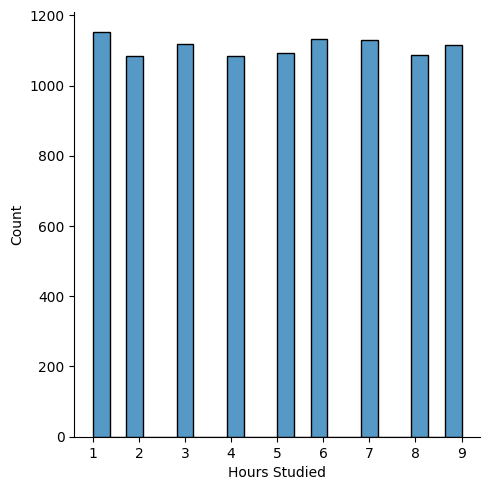

0.004501683134743138


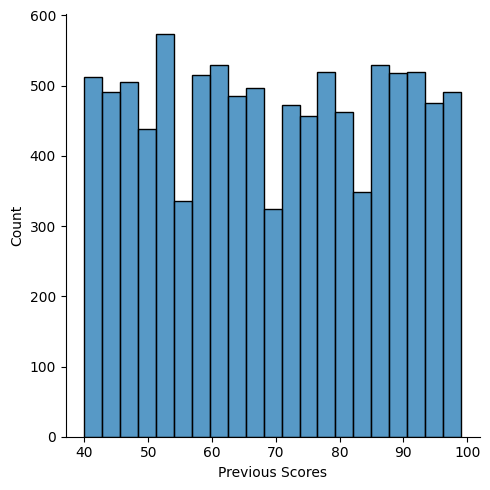

0.020804245722150994


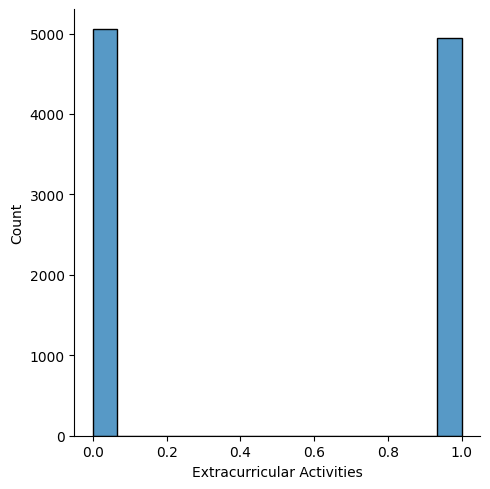

-0.03947379005452839


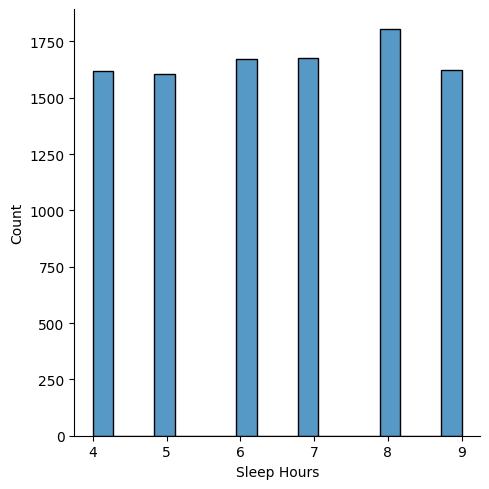

-0.035635999762971604


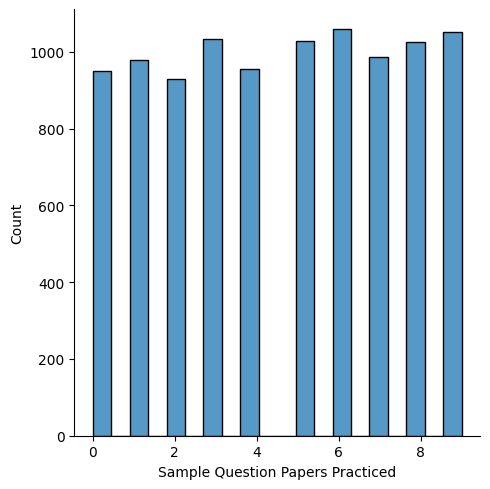

-0.0017400273072201125


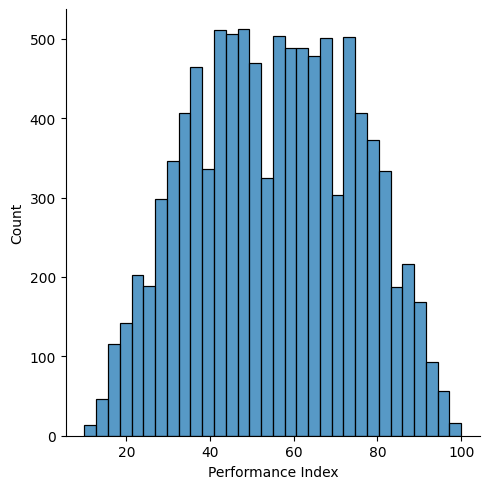

In [14]:
# Distribution of each variable

for i in data.columns:
    sns.displot(x = data[i])
    print(data[i].skew())
    plt.show()

**Training Test Dataset**

In [15]:
# Importing library for training the dataset

from sklearn.model_selection import train_test_split

In [16]:
# We want all rows except last column (Independent var) excluding performance index column

x = data.iloc[:,[0,1,2,3,4]]
x.head(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2


In [17]:
# Dependent Variable only performance index column

y = data.iloc[:, 5]
y.head(3)

0    91.0
1    65.0
2    45.0
Name: Performance Index, dtype: float64

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2)

In [19]:
# Output: Traning 8000 records

x_train.shape, y_train.shape

((8000, 5), (8000,))

In [20]:
# Output: 2000 rows testing

x_test.shape, y_test.shape

((2000, 5), (2000,))

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
print(model)

LinearRegression()


In [24]:
# Traning the data on Regression model

print('Model Traning -----')
model.fit(x_train, y_train)

Model Traning -----


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.61,0.47,0.2 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-34.04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [25]:
# Coefficients and Intecepts

model.coef_

array([2.85123995, 1.01822184, 0.61350748, 0.47438479, 0.19912786])

In [26]:
model.intercept_

-34.036188472133134

- Formula y = mx + c
- y = (-0.97312465\*1) + (-0.3558784\*2) + 16.02924307

## Model Validation

In [27]:
pred = model.predict(x_test)        # Passing input record

In [28]:
pred        # All 2000 Values Predicted

array([28.65941864, 51.54524914, 34.02428151, ..., 51.67574926,
       57.04641307, 86.78667624])

In [29]:
from sklearn.metrics import r2_score

In [52]:
# Checking the accuracy

acc = round(r2_score(y_test, pred)*100, 2)
print(f"Accuracy of the model is {acc}")

Accuracy of the model is 98.89


Model is giving us 98.89% of accuracy 

In [31]:
y_test.head(3)

1440    24.0
7581    50.0
1137    32.0
Name: Performance Index, dtype: float64

In [32]:
pred

array([28.65941864, 51.54524914, 34.02428151, ..., 51.67574926,
       57.04641307, 86.78667624])

In [33]:
#  Comparing the actual data test result

pd.DataFrame({"Actual_Data": y_test, "Predicted Data": pred})

,Actual_Data,Predicted Data
1440,24.0,28.659419
7581,50.0,51.545249
1137,32.0,34.024282
7650,33.0,31.844393
4328,37.0,33.223691
...,...,...
7137,26.0,26.003009
6376,44.0,41.346665
3899,50.0,51.675749
2608,58.0,57.046413


In [34]:
# Calculating the error percentage

error_percentage = round(100-acc,2)
error_percentage 

1.11

In [40]:
x_test.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced'],
      dtype='object')

<Axes: xlabel='Previous Scores'>

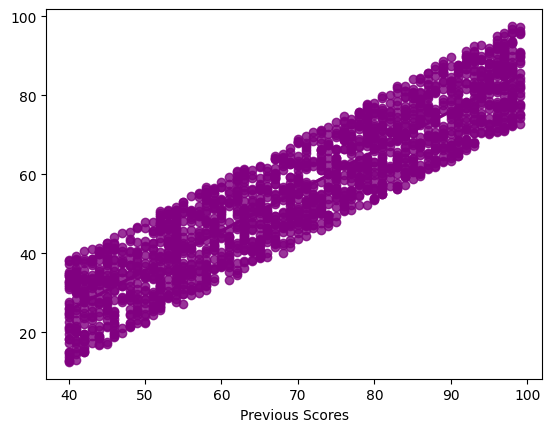

In [49]:
sns.regplot(x = x_test['Previous Scores'], y = pred, color='Purple')

Saving the Model

In [53]:
import joblib

In [54]:
joblib.dump(model, 'ML_Regression_model_v1.ipynb')

['ML_Regression_model_v1.ipynb']

In [55]:
load_model = joblib.load('ML_Regression_model_v1.ipynb')
print(load_model)

LinearRegression()


### So if any new data comes in future it will use the model and will give predicted values.

In [56]:
load_model.predict(x_test)

array([28.65941864, 51.54524914, 34.02428151, ..., 51.67574926,
       57.04641307, 86.78667624])

Suppose we give randome value to model

In [ ]:


x_new = [[10, 50, 3, 1, 0]]

In [58]:
load_model.predict(x_new)

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([47.70221005])

### Machine Learning modeling steps we followed 
1. Loaded the data
2. EDA
3. Sampling (Train & Tested)
4. Model Validation
5. Save the Model
6. Predicted the new data